<a href="https://colab.research.google.com/github/RishikaBhawsingka/NLP-ML-project/blob/main/EDA4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from datasets import load_dataset

dataset = load_dataset("google-research-datasets/go_emotions")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [ ]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("google-research-datasets/go_emotions")

train_df = pd.DataFrame(dataset["train"])
validation_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

train_df.to_csv("train.csv", index=False)
validation_df.to_csv("validation.csv", index=False)
test_df.to_csv("test.csv", index=False)

In [ ]:
train = pd.read_csv("/content/train.csv")
validation = pd.read_csv("/content/validation.csv")
test = pd.read_csv("/content/test.csv")

In [ ]:
train.head()
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43410 entries, 0 to 43409
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    43410 non-null  object
 1   labels  43410 non-null  object
 2   id      43410 non-null  object
dtypes: object(3)
memory usage: 1017.6+ KB


In [ ]:
test.shape
train.shape
validation.shape
"""train.shape -> (43410 , 3)
Validation.shape -> (5426 , 3)
Test.shape -> (5427 , 3) """


(5426, 3)

In [ ]:

""" there is no null and duplicate in train.csv"""
train.columns
train['labels'].value_counts()

,count
labels,
[27],12823
[0],2710
[4],1873
[15],1857
[1],1652
...,...
"[0, 4, 9, 18]",1
"[3, 9, 26]",1
"[0, 8, 15, 17]",1


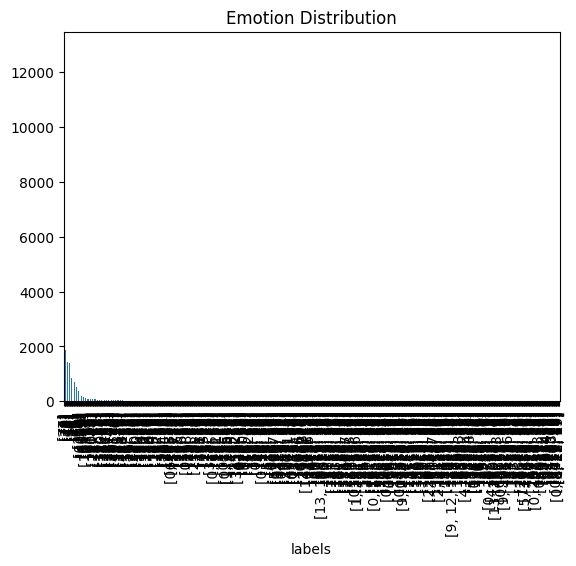

In [ ]:
import matplotlib.pyplot as plt
train['labels'].value_counts().plot(kind='bar')
plt.title("Emotion Distribution")
plt.show()

In [ ]:
train['labels'].unique()

AttributeError: 'numpy.ndarray' object has no attribute 'count'

In [ ]:
import ast

train["label"] = train["labels"].apply(lambda x: ast.literal_eval(x)[0])

validation["label"] = validation["labels"].apply(lambda x: ast.literal_eval(x)[0])

test["label"] = test["labels"].apply(lambda x: ast.literal_eval(x)[0])

In [ ]:
train.head()

,text,labels,id,emotion,label
0,My favourite food is anything I didn't have to...,[27],eebbqej,NaN,27
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i,NaN,27
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj,NaN,2
3,To make her feel threatened,[14],ed7ypvh,NaN,14
4,Dirty Southern Wankers,[3],ed0bdzj,NaN,3


In [ ]:
emotion_map = {
0:"admiration",
1:"amusement",
2:"anger",
3:"annoyance",
4:"approval",
5:"caring",
6:"confusion",
7:"curiosity",
8:"desire",
9:"disappointment",
10:"disapproval",
11:"disgust",
12:"embarrassment",
13:"excitement",
14:"fear",
15:"gratitude",
16:"grief",
17:"joy",
18:"love",
19:"nervousness",
20:"optimism",
21:"pride",
22:"realization",
23:"relief",
24:"remorse",
25:"sadness",
26:"surprise",
27:"neutral"
}

In [ ]:
train["emotion"] = train["label"].map(emotion_map)

validation["emotion"] = validation["label"].map(emotion_map)

test["emotion"] = test["label"].map(emotion_map)

In [ ]:
train.head()

,text,labels,id,emotion,label
0,My favourite food is anything I didn't have to...,[27],eebbqej,neutral,27
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i,neutral,27
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj,anger,2
3,To make her feel threatened,[14],ed7ypvh,fear,14
4,Dirty Southern Wankers,[3],ed0bdzj,annoyance,3


In [ ]:
train["emotion"].value_counts()

,count
emotion,
neutral,12823
admiration,4130
approval,2596
amusement,2244
annoyance,2138
gratitude,2096
curiosity,1772
disapproval,1651
anger,1547


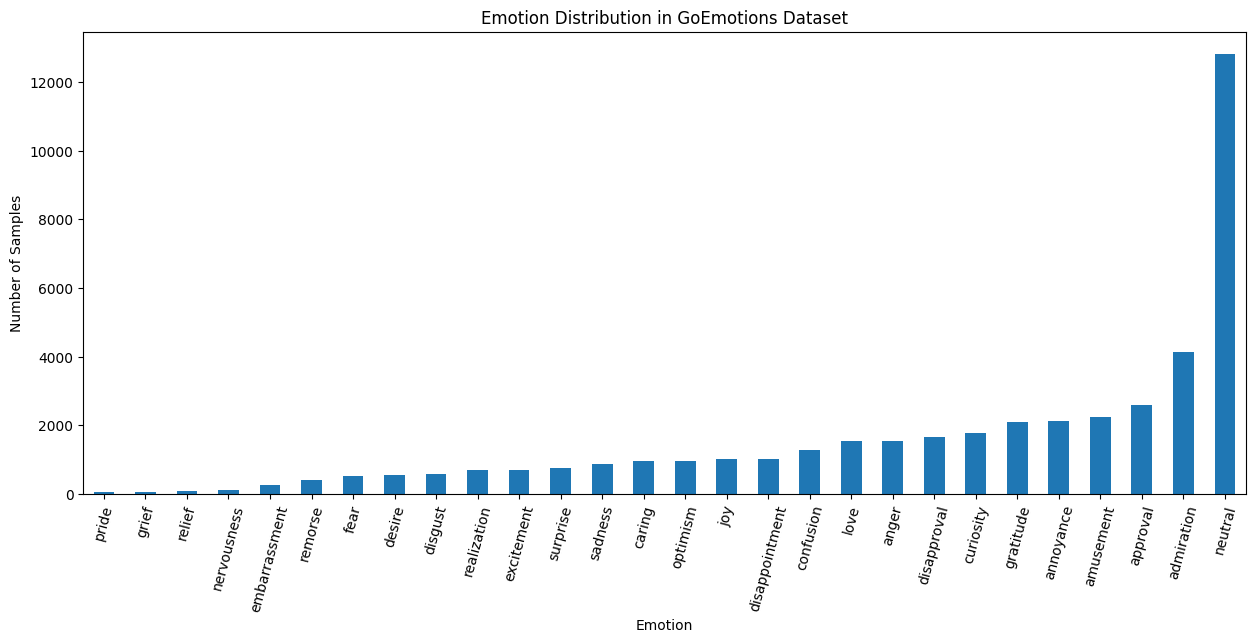

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

train["emotion"].value_counts().sort_values().plot(kind="bar")

plt.title("Emotion Distribution in GoEmotions Dataset")

plt.xlabel("Emotion")

plt.ylabel("Number of Samples")

plt.xticks(rotation=75)

plt.show()

In [ ]:
train.isnull().sum()
""" no missing value and duplicate row  in train"""

,0
text,0
labels,0
id,0
emotion,0
label,0


In [ ]:
train["word_count"] = train["text"].apply(lambda x: len(x.split()))

In [ ]:
train["word_count"].describe()

,word_count
count,43410.000000
mean,12.840175
std,6.701597
min,1.000000
25%,7.000000
50%,12.000000
75%,18.000000
max,33.000000


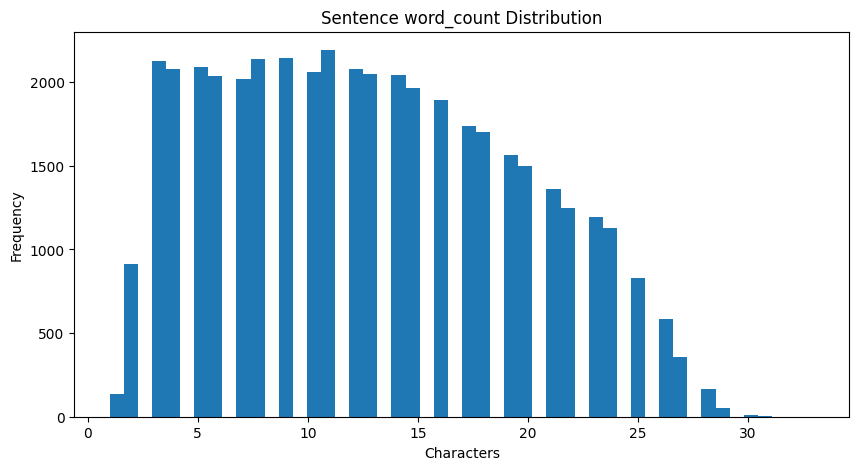

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(train["word_count"], bins=50)

plt.title("Sentence word_count Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [ ]:
train.sample(10)

,text,labels,id,emotion,label,length,word_count
22165,I feel bad for him and [NAME] i hate seeing th...,[25],eehfyfb,sadness,25,69,14
24924,"Oh yeah, it's really dehumanizing to have resp...",[3],edoraiq,annoyance,3,134,23
18067,Isn't that redundant?,[6],edy9q8t,confusion,6,21,3
19546,Become proficient with firearms and learn a se...,[5],edn9jl8,caring,5,97,17
5370,good luck stay safe!💓,[5],effcdq5,caring,5,21,4
26855,*IIII blessss the eeggsss!!!!*,[27],ed6jn50,neutral,27,30,4
40710,I honestly can't remember how many things ende...,[6],ee638uw,confusion,6,132,24
37239,You think only a -couple- people use fgt hatef...,[7],eempv12,curiosity,7,51,9
25635,Dont ask about Missouri. Ask about the towns i...,[27],eebuore,neutral,27,108,18
42907,RemindMe! 3 Days,[27],ef2ot38,neutral,27,16,3
